Workflow Fundamentals 

1. ready data
    - turn data into tensors 

2. build/pick pre trained model
    - pick a loss function & optimizer
    - build training loop/ pipeline?

3. fit model and make prediction

4. evaluate

5. improve

6. Save and reload trained model

In [72]:
import torch
from torch import nn
import matplotlib.pyplot as plt

1. Data preparing and loading

In [73]:
#create known parameters?

weight= 0.7
bias= 0.3

#create data

start= 0
end= 1
step= 0.02
X= torch.arange(start, end, step).unsqueeze(dim=1)
y= weight * X * bias

print(X[:10]) 
print(y[:10])


tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]])
tensor([[0.0000],
        [0.0042],
        [0.0084],
        [0.0126],
        [0.0168],
        [0.0210],
        [0.0252],
        [0.0294],
        [0.0336],
        [0.0378]])


In [74]:
train_split= int(0.8 * len(X))

X_train, y_train= X[:train_split], y[:train_split]
X_test, y_test= X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

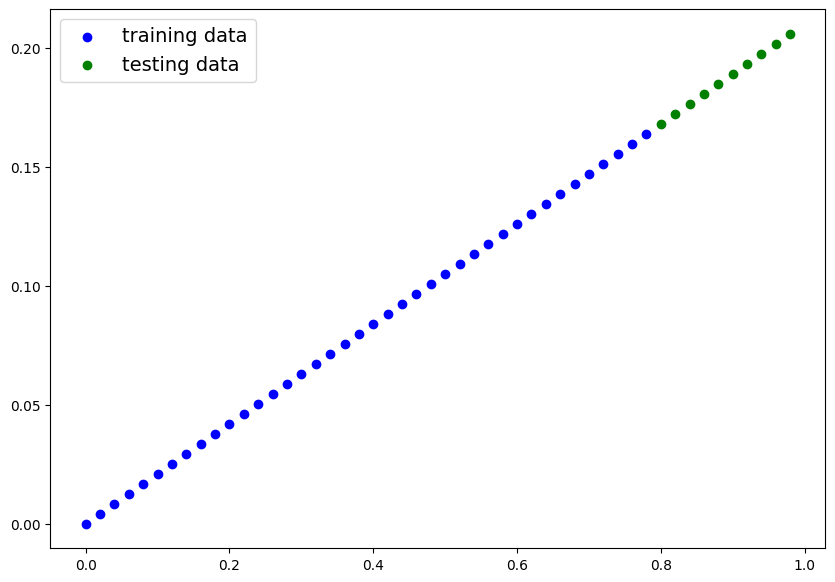

In [75]:
def plot_predictions(
        X_train= X_train,
        y_train= y_train,
        X_test= X_test,
        y_test= y_test,
        predictions= None):
    
    plt.figure(figsize=(10,7))

    plt.scatter(X_train, y_train, c='b', label= 'training data')
    plt.scatter(X_test, y_test, c='g', label= 'testing data')

    if predictions is not None:
        plt.scatter(X_test, predictions, c='r', label= 'predictions')

    plt.legend(prop={'size':14})

plot_predictions()

2. Building model

PyTorch building essentials:
    
 - torch.nn
 - torch.optim
 - torch.utils.data.Dataset
 - torch.utils.data.DataLoader

1. torch.nn
- Du använder torch.nn när du vill bygga lager, loss functions och modeller.
    - verktygslådan
        - nn.Linear()
        - nn.ReLU()
        - nn.Conv2d()
        - nn.CrossEntropyLoss()

2. nn.Module 
    - basklassen för modellen
    nn.Module gör att PyTorch kan hålla koll på:
    - lager
    - vikter
    - parametrar
    - GPU/CPU
    - train/eval mode
    - spara/ladda modellen

3. nn.Parameter
    - träningsbara vikter

4. torch.optim
    - algoritmen som updaterar vikterna
    
    detta inehåller opitmizers
    - En optimizer är det som uppdaterar modellens vikter efter att modellen har räknat ut sitt fel
    vanliga opimizers:
    - torch.optim.SGD
    - torch.optim.Adam
    ex: optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

5. forward()
    - vad modellen gör med input/ där man använder lagren på data


input → forward() → output → loss → optimizer uppdaterar vikter


In [76]:

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                 dtype=torch.float32), requires_grad=True)  # <- can we update this value with gradient descent?

        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float32), requires_grad=True)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias
    

model= LinearRegressionModel()

torch.manual_seed(seed=42)

# print(model.weights)
# print(model.bias)
# print(model(X_train))

list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

Making predictions 

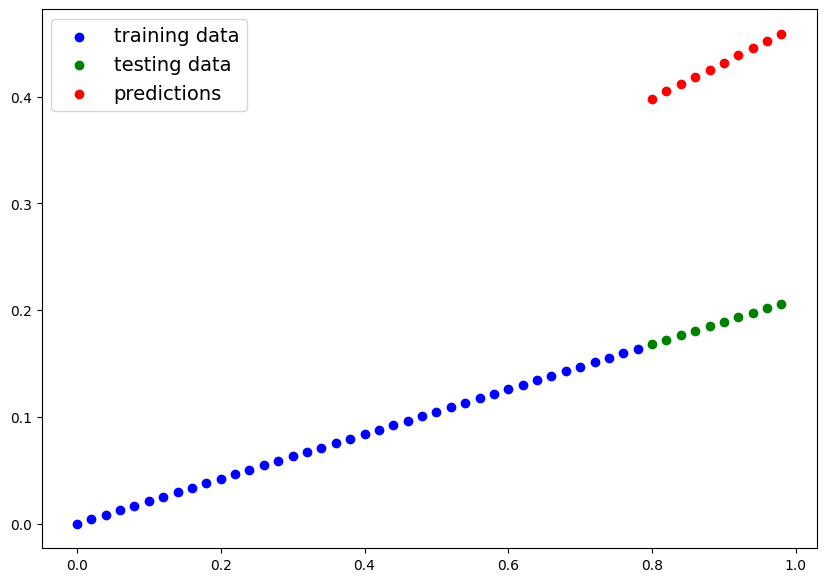

In [77]:
with torch.inference_mode():
    y_preds= model(X_test)



plot_predictions(predictions=y_preds)

Loss funtion mäter hur mycket fel modellen har. Finns i torch.nn

opimizer berättar för modellen hur den ska updatera sina parmetrar för att sänka loss. torch.optim
- vanliga optimizers: torch.optim.SGD()  torch.optim.Adam()



In [78]:
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(params=model.parameters(), # parameters of target model to optimize
                            lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Training loop

1. forward pass.     model(X)
    - går igenom träningsdatan och kör forward()

2. calculate the loss.   loss= loss_fn(y_preds, y_train)
    - modellen jämnför skillnadem mellan modellens svar och det riktiga svaret

3. zero gradients.   opimizer.zero_grad()
    - opimizer gradientsen sätts till 0 så dem kan börja om på nästa steg. gradients är instruktioner för hur vikten ska ändras/ vilket håll?

4. perform backpropagation on the loss.  loss.backward()
    - räknar ut gradients/ instruktionerna

5. update the optimizer. (gradient decent). opimizer.step()
    ändrar vikterna 

In [79]:
#Ex
epochs=100

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    #put in training mode
    model.train()

    #1. forwardpass
    y_pred=model(X_train)

    #2. calculate loss
    loss= loss_fn(y_pred, y_train)

    #3.  zero gradients
    optimizer.zero_grad()

    #4. backpropagation
    loss.backward()

    #5. update optimizer, step
    optimizer.step()


    #testing del
    model.eval()
    with torch.inference_mode():
        y_preds= model(X_test)

        # 2. Caculate loss on test data
        test_loss = loss_fn(y_preds, y_test.type(torch.float))

    if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.17821863293647766 | MAE Test Loss: 0.22809283435344696 
Epoch: 10 | MAE Train Loss: 0.06300870329141617 | MAE Test Loss: 0.09338293969631195 
Epoch: 20 | MAE Train Loss: 0.01129001285880804 | MAE Test Loss: 0.025797033682465553 
Epoch: 30 | MAE Train Loss: 0.007851206697523594 | MAE Test Loss: 0.0175245963037014 
Epoch: 40 | MAE Train Loss: 0.0044124070554971695 | MAE Test Loss: 0.009252198040485382 
Epoch: 50 | MAE Train Loss: 0.009151091799139977 | MAE Test Loss: 0.0006053060060366988 
Epoch: 60 | MAE Train Loss: 0.009151091799139977 | MAE Test Loss: 0.0006053060060366988 
Epoch: 70 | MAE Train Loss: 0.009151091799139977 | MAE Test Loss: 0.0006053060060366988 
Epoch: 80 | MAE Train Loss: 0.009151091799139977 | MAE Test Loss: 0.0006053060060366988 
Epoch: 90 | MAE Train Loss: 0.009151091799139977 | MAE Test Loss: 0.0006053060060366988 


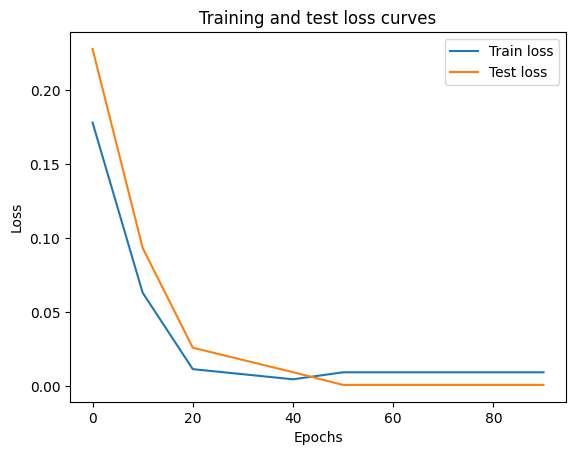

In [80]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

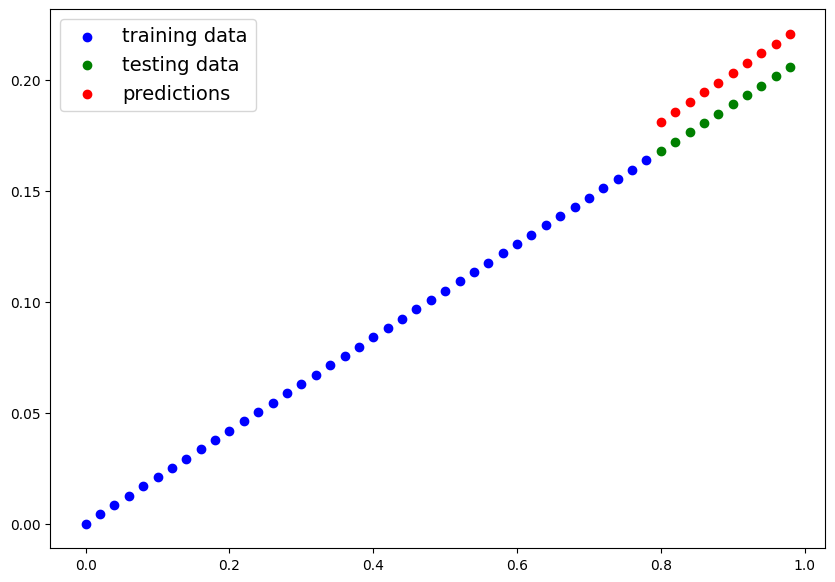

In [81]:




plot_predictions(predictions=y_preds)